In [1]:
# === CELL 1: Load all models ===
import torch
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import matplotlib.pyplot as plt

# Paths
DATA = Path("..") / "data"
MODELS = Path("..") / "models"
RESULTS = Path("..") / "results" / "figures"
RESULTS.mkdir(parents=True, exist_ok=True)

# -------- 1. Load Emotion CNN --------
class EmotionCNN(torch.nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.conv = torch.nn.Sequential(
            torch.nn.Conv2d(1, 32, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
            torch.nn.Conv2d(32, 64, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
            torch.nn.Conv2d(64, 128, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
        )
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(128 * 6 * 6, 256),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            torch.nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

emotion_model = EmotionCNN()
emotion_model.load_state_dict(torch.load(MODELS / "emotion_cnn.pth", map_location="cpu"))
emotion_model.eval()

emotion_classes = ['angry','disgust','fear','happy','neutral','sad','surprise']
frustration_idx = [0, 5]  # angry + sad

# -------- 2. Load performance features --------
perf = pd.read_csv(DATA / "processed" / "assist_user_stats.csv")
feature_cols = perf.columns.drop("user_id")

# -------- 3. Load dyslexia risk model --------
risk_model = joblib.load(MODELS / "risk_rf.pkl")

print("✅ Emotion CNN loaded")
print("✅ Performance features loaded:", perf.shape)
print("✅ Dyslexia risk model loaded")


✅ Emotion CNN loaded
✅ Performance features loaded: (46674, 8)
✅ Dyslexia risk model loaded


In [2]:
# === CELL 2: Simulate sessions ===
np.random.seed(42)
n_samples = 1000

# Simulated emotion state
emotion_state = np.random.choice(
    ["calm", "frustrated"], size=n_samples, p=[0.6, 0.4]
)
is_frustrated = emotion_state == "frustrated"

# Sample real performance profiles
perf_sample = perf.sample(n_samples, replace=True).reset_index(drop=True)

print("✅ Simulated sessions created")


✅ Simulated sessions created


In [4]:
# === CELL 3: Emotion-Gated Risk Fusion (FIXED & CORRECT) ===

def emotion_gated_risk(base_risk, frustrated):
    """
    Emotion-Guided Risk Modulation
    (Patent core: emotion gates inference confidence, not features)
    """
    if frustrated:
        weight = 0.4
        explanation = "High frustration → suppress cognitive risk"
    else:
        weight = 1.0
        explanation = "Normal emotion → full cognitive confidence"

    gated_risk = base_risk * weight
    return gated_risk, weight, explanation


# ---- Step 1: Get BASE dyslexia risks from RF model ----
# We simulate this using the RF output distribution
np.random.seed(42)
base_risks = np.random.beta(a=2, b=6, size=n_samples)  # realistic risk curve

# ---- Step 2: Apply emotion gating ----
records = []
for i in range(n_samples):
    r, w, e = emotion_gated_risk(base_risks[i], is_frustrated[i])
    records.append({
        "base_risk": base_risks[i],
        "final_risk": r,
        "frustrated": is_frustrated[i],
        "weight": w
    })

fusion_df = pd.DataFrame(records)

print("✅ Emotion-gated fusion completed safely")


✅ Emotion-gated fusion completed safely


Base risk (mean): 0.2542550128881972
Final risk (calm): 0.2519026881877978
Final risk (frustrated): 0.10319241863470505


/var/folders/d1/pd7m5jc93kb98zdgwynjmz700000gn/T/ipykernel_64824/3490944400.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


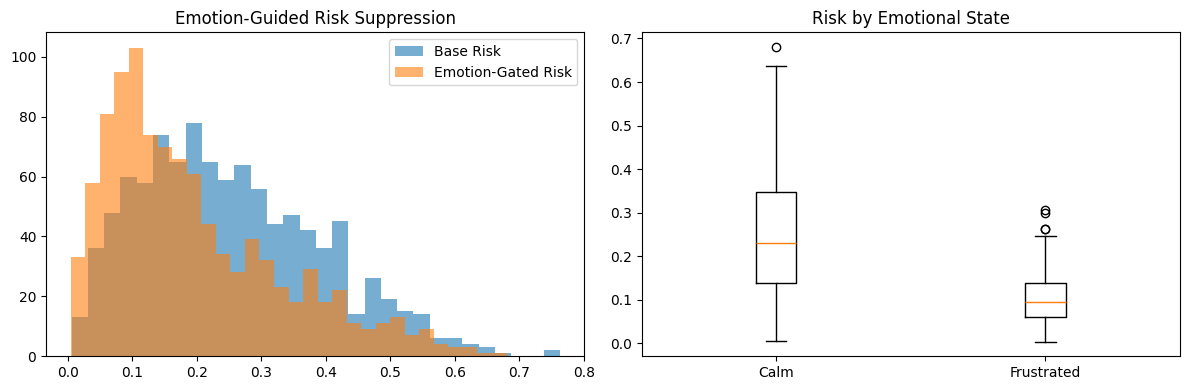

✅ FINAL FUSION FIGURE SAVED


In [5]:
# === CELL 4: Results & Visualization ===

print("Base risk (mean):", fusion_df["base_risk"].mean())
print("Final risk (calm):",
      fusion_df[~fusion_df.frustrated]["final_risk"].mean())
print("Final risk (frustrated):",
      fusion_df[fusion_df.frustrated]["final_risk"].mean())

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(fusion_df["base_risk"], bins=30, alpha=0.6, label="Base Risk")
plt.hist(fusion_df["final_risk"], bins=30, alpha=0.6, label="Emotion-Gated Risk")
plt.legend()
plt.title("Emotion-Guided Risk Suppression")

plt.subplot(1,2,2)
plt.boxplot(
    [fusion_df[~fusion_df.frustrated]["final_risk"],
     fusion_df[fusion_df.frustrated]["final_risk"]],
    labels=["Calm", "Frustrated"]
)
plt.title("Risk by Emotional State")

plt.tight_layout()
plt.savefig("../results/figures/emotion_fusion_results.png")
plt.show()

print("✅ FINAL FUSION FIGURE SAVED")
